# Krok 5 — Random Forest Regressor

| Položka | Hodnota |
|---------|---------|
| **Projekt** | CLV Predikce 2025 |
| **Krok** | 5 / 7 |
| **Datum** | 2025-06-01 |
| **Autor** | Datový analytik |
| **Verze** | 1.0 |

**Cíl notebooku:**  
Natrénovat Random Forest Regressor s hyperparameter tuningem přes GridSearchCV.  
Porovnat výsledky s lineární regresí (Krok 3) v přehledné tabulce metrik.  
Vizualizovat feature importance a residuální analýzu. Random Forest tvoří  
přechodový model mezi interpretovatelným baseline a výkonným XGBoostem (Krok 6).

---
### Poznámka k metodě před začátkem kódování

**Výhody Random Forest pro CLV predikci:**  
Stromy jsou invariantní vůči škálování features — StandardScaler není nutný,  
ale winzorizaci trend-features zachováme z důvodu konzistence a potlačení  
extrémních split kritérií. RF přirozeně zvládá multikolinearitu (která trápila  
lineární regresi) a zachycuje nelineární vztahy bez explicitní transformace targetu.

**GridSearchCV strategie:**  
Prohledáváme 36 kombinací hyperparametrů (`n_estimators` × `max_depth` ×  
`min_samples_leaf` × `max_features`) přes 5-fold CV s metrikou MAE.  
Celkem 180 fitů — výpočetně náročnější, ale spolehlivý odhad generalizačního výkonu.


## 2. Imports & Setup

In [1]:
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import (
    GridSearchCV,
    cross_val_score,
    train_test_split,
)

warnings.filterwarnings("ignore")

RANDOM_STATE    = 42
TEST_SIZE       = 0.2
CV_FOLDS        = 5
WINSOR_QUANTILE = 0.99

INPUT_DIR  = Path("outputs")
OUTPUT_DIR = Path("outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 120
plt.rcParams["font.size"] = 11

print("Prostředí inicializováno.")


Prostředí inicializováno.


## 3. Načtení dat

In [2]:
try:
    df = pd.read_csv(INPUT_DIR / "step_02_features.csv")
    metrics_lr = pd.read_csv(INPUT_DIR / "step_03_metrics.csv")
    print(f"✅ Feature tabulka načtena: {df.shape}")
    print(f"✅ Metriky LR načteny.")
except FileNotFoundError as e:
    raise FileNotFoundError(f"Výstup předchozího kroku nenalezen: {e}")

df.head(3)


✅ Feature tabulka načtena: (1200, 32)
✅ Metriky LR načteny.


,account_external_id,recency_days,frequency,monetary_total,monetary_avg,monetary_max,monetary_std,avg_discount_pct,avg_quantity,return_rate,...,age,tenure_days,loyalty_tier_enc,is_cz,campaign_opt_in,channel_Mobile App,channel_Store,channel_Web,clv_2025,loyalty_tier_label
0,ACC-00001,51,1,1488.74,1488.74,1488.74,0.000000,0.0,1.0,0.000000,...,39,138,1,1,0,0,1,0,0.00,Bronze
1,ACC-00002,59,5,18051.50,3610.30,9119.84,3385.600399,9.0,1.4,0.166667,...,48,466,2,1,1,1,0,0,5768.04,Silver
2,ACC-00003,527,2,5855.62,2927.81,3218.22,410.701761,7.5,1.5,0.000000,...,34,652,2,1,0,0,0,0,1998.03,Silver


## 4. Příprava dat

In [3]:
DROP_COLS    = ["account_external_id", "loyalty_tier_label", "clv_2025"]
FEATURE_COLS = [c for c in df.columns if c not in DROP_COLS]
TARGET_COL   = "clv_2025"

X = df[FEATURE_COLS].copy()
y = df[TARGET_COL].copy()

# Winzorizace trend-features — stejný preprocessing jako v Kroku 3
TREND_COLS = ["spend_trend_2y", "spend_trend_1y"]
for col in TREND_COLS:
    cap = X[col].quantile(WINSOR_QUANTILE)
    X[col] = X[col].clip(upper=cap)
    print(f"  {col}: cap = {cap:,.1f}")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE
)

# RF nepotřebuje StandardScaler — stromy jsou škálovací invariantní
print(f"\nTrénovací množina: {len(X_train)} zákazníků")
print(f"Testovací množina:  {len(X_test)} zákazníků")
print(f"Počet features:     {len(FEATURE_COLS)}")


  spend_trend_2y: cap = 98,996.6
  spend_trend_1y: cap = 64,806.4

Trénovací množina: 960 zákazníků
Testovací množina:  240 zákazníků
Počet features:     29


## 5. Hyperparameter tuning — GridSearchCV

In [4]:
# Mřížka hyperparametrů
PARAM_GRID = {
    "n_estimators":    [200, 400],
    "max_depth":       [10, 20, None],
    "min_samples_leaf":[1, 5, 10],
    "max_features":    [0.5, "sqrt"],
}

n_combinations = (
    len(PARAM_GRID["n_estimators"])
    * len(PARAM_GRID["max_depth"])
    * len(PARAM_GRID["min_samples_leaf"])
    * len(PARAM_GRID["max_features"])
)
print(f"Počet kombinací hyperparametrů: {n_combinations}")
print(f"Celkem fitů (× {CV_FOLDS} foldů):       {n_combinations * CV_FOLDS}")
print("Spouštím GridSearchCV (může trvat 2–3 minuty)...")


Počet kombinací hyperparametrů: 36
Celkem fitů (× 5 foldů):       180
Spouštím GridSearchCV (může trvat 2–3 minuty)...


In [5]:
rf_base = RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1)

grid_search = GridSearchCV(
    estimator=rf_base,
    param_grid=PARAM_GRID,
    cv=CV_FOLDS,
    scoring="neg_mean_absolute_error",
    n_jobs=-1,
    verbose=0,
    refit=True,         # automaticky natrénuje nejlepší model na celém train setu
)
grid_search.fit(X_train, y_train)

print(f"✅ GridSearchCV dokončen.")
print(f"\nNejlepší hyperparametry:")
for param, val in grid_search.best_params_.items():
    print(f"  {param}: {val}")
print(f"\nNejlepší CV MAE (train): {-grid_search.best_score_:,.0f}")


✅ GridSearchCV dokončen.

Nejlepší hyperparametry:
  max_depth: 20
  max_features: 0.5
  min_samples_leaf: 5
  n_estimators: 200

Nejlepší CV MAE (train): 7,879


### 5.1 Přehled výsledků GridSearch (top 10 kombinací)

In [6]:
cv_results = pd.DataFrame(grid_search.cv_results_)

top10_grid = (
    cv_results[[
        "param_n_estimators", "param_max_depth",
        "param_min_samples_leaf", "param_max_features",
        "mean_test_score", "std_test_score", "rank_test_score",
    ]]
    .assign(
        mean_MAE = lambda d: (-d["mean_test_score"]).round(0).astype(int),
        std_MAE  = lambda d: d["std_test_score"].round(0).astype(int),
    )
    .sort_values("rank_test_score")
    .head(10)
    .rename(columns={
        "param_n_estimators":     "n_estimators",
        "param_max_depth":        "max_depth",
        "param_min_samples_leaf": "min_samples_leaf",
        "param_max_features":     "max_features",
        "rank_test_score":        "rank",
    })
    [["rank", "n_estimators", "max_depth", "min_samples_leaf",
      "max_features", "mean_MAE", "std_MAE"]]
    .reset_index(drop=True)
)
display(top10_grid)


,rank,n_estimators,max_depth,min_samples_leaf,max_features,mean_MAE,std_MAE
0,1,200,20,5,0.5,7879,1071
1,1,200,None,5,0.5,7879,1071
2,3,400,None,5,0.5,7892,1106
3,3,400,20,5,0.5,7892,1106
4,5,400,10,5,0.5,7899,1082
5,6,200,10,5,0.5,7904,1073
6,7,400,10,1,0.5,8018,1171
7,8,200,20,10,0.5,8021,1003
8,8,200,None,10,0.5,8021,1003
9,10,200,10,1,0.5,8028,1201


## 6. Evaluace nejlepšího modelu

In [7]:
# grid_search.best_estimator_ je již natrénovaný na celém X_train (refit=True)
best_rf = grid_search.best_estimator_

y_pred_raw = best_rf.predict(X_test)
y_pred = np.maximum(y_pred_raw, 0)     # záporné hodnoty nemají smysl

n_negative = (y_pred_raw < 0).sum()
print(f"Záporné predikce před clippingem: {n_negative} / {len(y_pred_raw)}")


Záporné predikce před clippingem: 0 / 240


## 7. Výsledky & Metriky

In [8]:
mae  = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2   = r2_score(y_test, y_pred)
mdae = np.median(np.abs(y_test.values - y_pred))

mask_active = y_test > 0
mae_active = mean_absolute_error(y_test[mask_active], y_pred[mask_active])
r2_active  = r2_score(y_test[mask_active], y_pred[mask_active])

# CV na trénovací množině s nejlepšími parametry
cv_mae = -cross_val_score(
    best_rf, X_train, y_train,
    cv=CV_FOLDS, scoring="neg_mean_absolute_error", n_jobs=-1,
)
cv_r2 = cross_val_score(
    best_rf, X_train, y_train,
    cv=CV_FOLDS, scoring="r2", n_jobs=-1,
)

metrics_rf = pd.DataFrame({
    "Metrika": [
        "MAE (všichni zákazníci)",
        "MdAE (medián abs. chyby)",
        "RMSE",
        "R² (všichni zákazníci)",
        "MAE (pouze aktivní, CLV>0)",
        "R² (pouze aktivní, CLV>0)",
        "CV MAE průměr (train)",
        "CV R² průměr (train)",
    ],
    "Hodnota": [
        f"{mae:,.0f}",
        f"{mdae:,.0f}",
        f"{rmse:,.0f}",
        f"{r2:.4f}",
        f"{mae_active:,.0f}",
        f"{r2_active:.4f}",
        f"{cv_mae.mean():,.0f} ± {cv_mae.std():,.0f}",
        f"{cv_r2.mean():.4f} ± {cv_r2.std():.4f}",
    ],
})
display(metrics_rf)


,Metrika,Hodnota
0,MAE (všichni zákazníci),"8,406"
1,MdAE (medián abs. chyby),"3,657"
2,RMSE,"16,212"
3,R² (všichni zákazníci),0.4771
4,"MAE (pouze aktivní, CLV>0)","14,153"
5,"R² (pouze aktivní, CLV>0)",0.3276
6,CV MAE průměr (train),"7,879 ± 1,071"
7,CV R² průměr (train),0.4668 ± 0.0460


### 7.1 Srovnávací tabulka: Random Forest vs. Lineární regrese

In [9]:
# Načteme metriky LR z Kroku 3 a přidáme RF
comparison = pd.DataFrame({
    "Model": ["Lineární regrese (baseline)", "Random Forest (tuned)"],
    "MAE":   [
        int(metrics_lr.loc[0, "MAE"]),
        int(mae),
    ],
    "RMSE":  [
        int(metrics_lr.loc[0, "RMSE"]),
        int(rmse),
    ],
    "R²":    [
        metrics_lr.loc[0, "R2"],
        round(r2, 4),
    ],
    "MAE (aktivní)": [
        int(metrics_lr.loc[0, "MAE_active"]),
        int(mae_active),
    ],
    "R² (aktivní)": [
        metrics_lr.loc[0, "R2_active"],
        round(r2_active, 4),
    ],
})

# Zvýraznění lepšího výsledku v každém sloupci
display(comparison.style
    .highlight_min(subset=["MAE", "RMSE", "MAE (aktivní)"], color="#d4edda")
    .highlight_max(subset=["R²", "R² (aktivní)"],            color="#d4edda")
    .format({"MAE": "{:,.0f}", "RMSE": "{:,.0f}",
             "MAE (aktivní)": "{:,.0f}",
             "R²": "{:.4f}", "R² (aktivní)": "{:.4f}"})
)

# Relativní zlepšení
mae_improvement  = (int(metrics_lr.loc[0, "MAE"]) - int(mae)) / int(metrics_lr.loc[0, "MAE"])
rmse_improvement = (int(metrics_lr.loc[0, "RMSE"]) - int(rmse)) / int(metrics_lr.loc[0, "RMSE"])
r2_improvement   = round(r2, 4) - metrics_lr.loc[0, "R2"]

print(f"\nZlepšení Random Forest vs. Lineární regrese:")
print(f"  MAE:  −{mae_improvement:.1%}  ({int(metrics_lr.loc[0, 'MAE']):,} → {int(mae):,})")
print(f"  RMSE: −{rmse_improvement:.1%}  ({int(metrics_lr.loc[0, 'RMSE']):,} → {int(rmse):,})")
print(f"  R²:   +{r2_improvement:.4f}  ({metrics_lr.loc[0, 'R2']:.4f} → {round(r2, 4):.4f})")


,Model,MAE,RMSE,R²,MAE (aktivní),R² (aktivní)
0,Lineární regrese (baseline),"9,708","17,101",0.4182,"15,185",0.2740
1,Random Forest (tuned),"8,406","16,212",0.4771,"14,152",0.3276



Zlepšení Random Forest vs. Lineární regrese:
  MAE:  −13.4%  (9,708 → 8,406)
  RMSE: −5.2%  (17,101 → 16,212)
  R²:   +0.0589  (0.4182 → 0.4771)


## 8. Vizualizace

### 8.1 Feature Importance

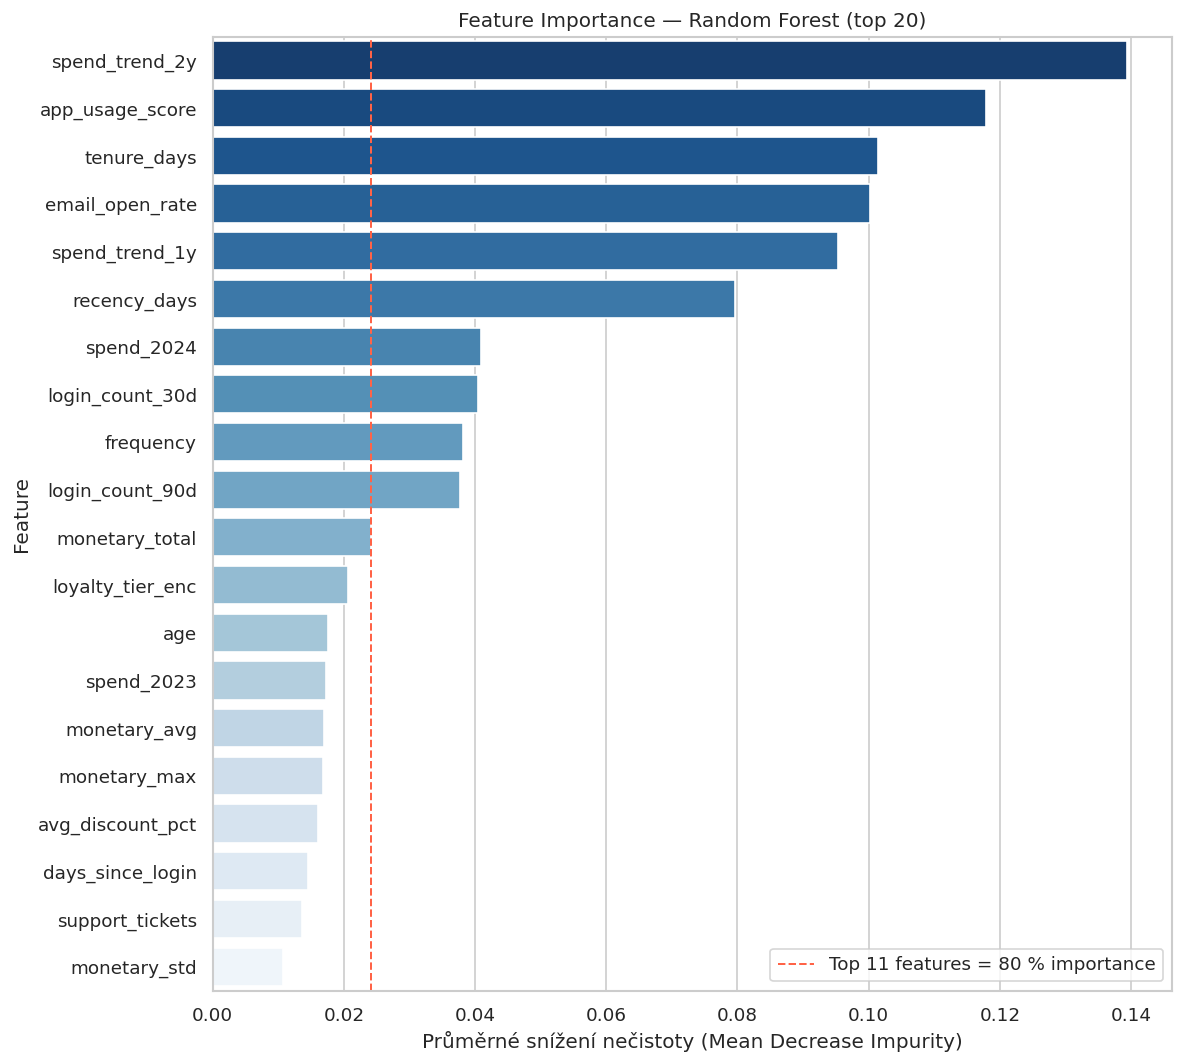


Top 11 features pokrývá 80 % celkové importance.
        feature  importance
 spend_trend_2y    0.139342
app_usage_score    0.117853
    tenure_days    0.101390
email_open_rate    0.100272
 spend_trend_1y    0.095325
   recency_days    0.079580
     spend_2024    0.040927
login_count_30d    0.040456
      frequency    0.038164
login_count_90d    0.037700
 monetary_total    0.024125


In [10]:
fi_df = (
    pd.DataFrame({
        "feature":    FEATURE_COLS,
        "importance": best_rf.feature_importances_,
    })
    .sort_values("importance", ascending=False)
    .reset_index(drop=True)
)

fig, ax = plt.subplots(figsize=(10, 9))

sns.barplot(
    data=fi_df.head(20),
    x="importance",
    y="feature",
    ax=ax,
    palette=sns.color_palette("Blues_r", n_colors=20),
    orient="h",
)
ax.set_title("Feature Importance — Random Forest (top 20)")
ax.set_xlabel("Průměrné snížení nečistoty (Mean Decrease Impurity)")
ax.set_ylabel("Feature")

# Kumulativní součet pro top features
cumsum = fi_df["importance"].cumsum()
top_n = (cumsum < 0.80).sum() + 1
ax.axvline(
    fi_df.loc[top_n - 1, "importance"],
    color="tomato", lw=1.2, linestyle="--",
    label=f"Top {top_n} features = 80 % importance",
)
ax.legend()

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "step_05_feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"\nTop {top_n} features pokrývá 80 % celkové importance.")
print(fi_df.head(top_n).to_string(index=False))


### 8.2 Predikované vs. skutečné hodnoty CLV 2025

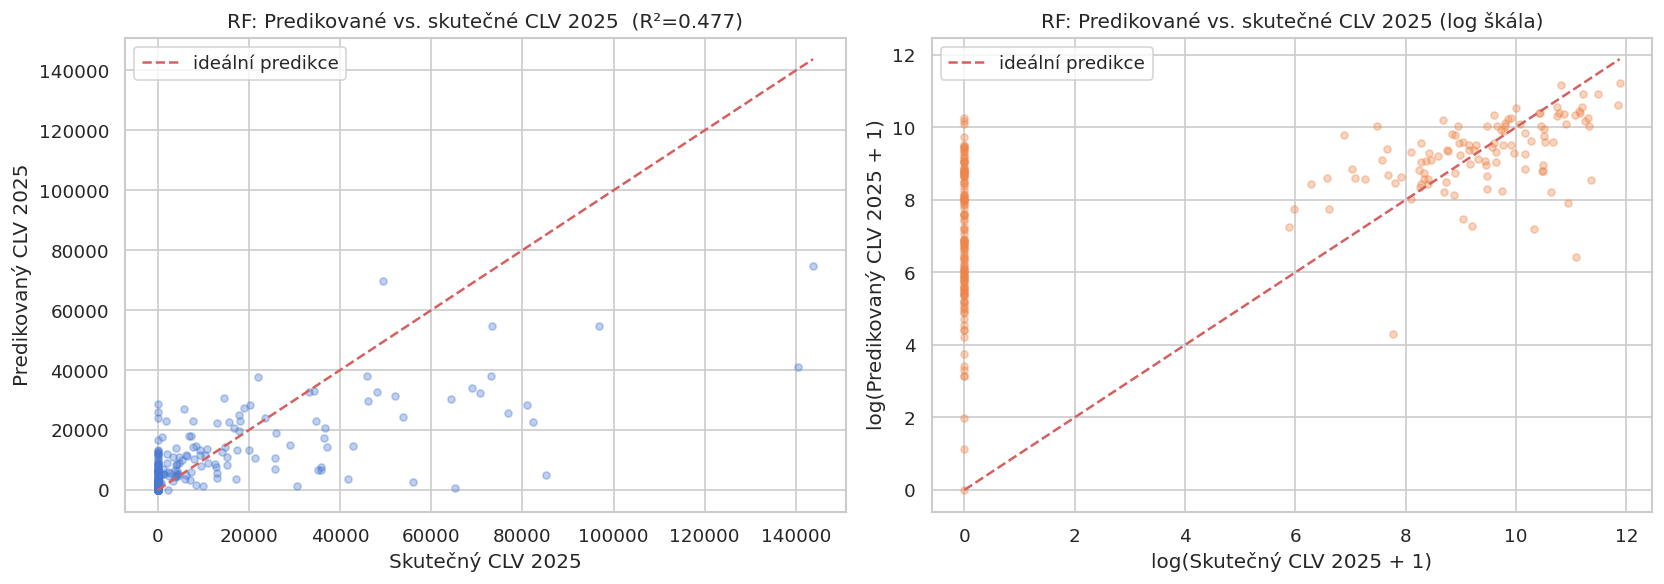

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Lineární škála
axes[0].scatter(
    y_test, y_pred,
    alpha=0.35, s=18,
    color=sns.color_palette("muted")[0],
)
max_val = max(y_test.max(), y_pred.max())
axes[0].plot([0, max_val], [0, max_val], "r--", lw=1.5, label="ideální predikce")
axes[0].set_title(f"RF: Predikované vs. skutečné CLV 2025  (R²={r2:.3f})")
axes[0].set_xlabel("Skutečný CLV 2025")
axes[0].set_ylabel("Predikovaný CLV 2025")
axes[0].legend()

# Log-log škála
axes[1].scatter(
    np.log1p(y_test), np.log1p(y_pred),
    alpha=0.35, s=18,
    color=sns.color_palette("muted")[1],
)
max_log = max(np.log1p(y_test).max(), np.log1p(y_pred).max())
axes[1].plot([0, max_log], [0, max_log], "r--", lw=1.5, label="ideální predikce")
axes[1].set_title("RF: Predikované vs. skutečné CLV 2025 (log škála)")
axes[1].set_xlabel("log(Skutečný CLV 2025 + 1)")
axes[1].set_ylabel("log(Predikovaný CLV 2025 + 1)")
axes[1].legend()

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "step_05_pred_vs_actual.png", dpi=150, bbox_inches="tight")
plt.show()


### 8.3 Residuální analýza

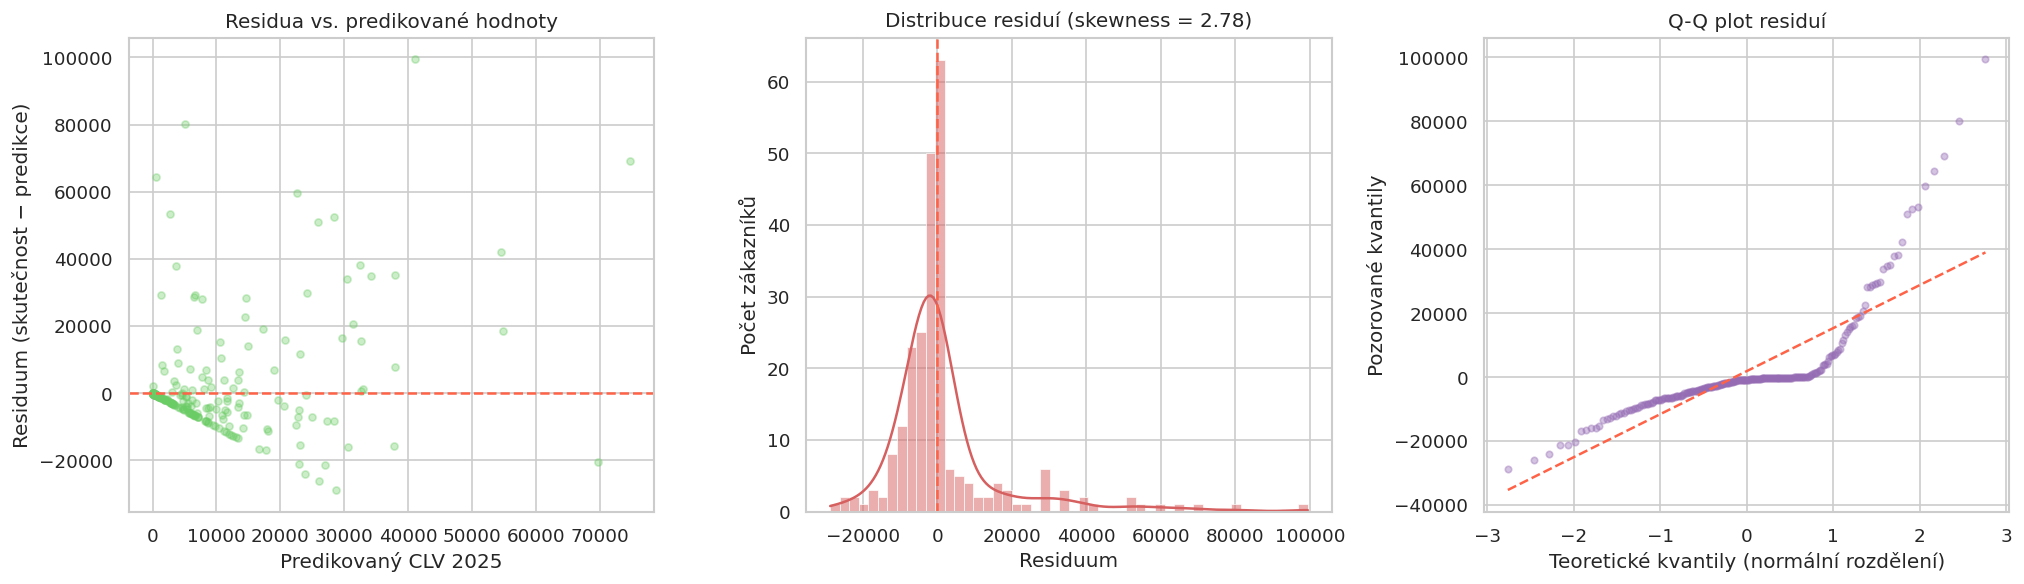

In [12]:
residuals = y_test.values - y_pred

fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# Residua vs. predikované hodnoty
axes[0].scatter(y_pred, residuals, alpha=0.35, s=18,
                color=sns.color_palette("muted")[2])
axes[0].axhline(0, color="tomato", lw=1.5, linestyle="--")
axes[0].set_title("Residua vs. predikované hodnoty")
axes[0].set_xlabel("Predikovaný CLV 2025")
axes[0].set_ylabel("Residuum (skutečnost − predikce)")

# Histogram residuí
sns.histplot(residuals, bins=50, ax=axes[1], kde=True,
             color=sns.color_palette("muted")[3],
             edgecolor="white", linewidth=0.4)
axes[1].axvline(0, color="tomato", lw=1.5, linestyle="--")
axes[1].set_title(
    f"Distribuce residuí (skewness = {pd.Series(residuals).skew():.2f})"
)
axes[1].set_xlabel("Residuum")
axes[1].set_ylabel("Počet zákazníků")

# Q-Q plot
from scipy import stats
(osm, osr), (slope, intercept, _) = stats.probplot(residuals, dist="norm")
axes[2].scatter(osm, osr, alpha=0.4, s=15,
                color=sns.color_palette("muted")[4])
axes[2].plot([osm[0], osm[-1]],
             [slope*osm[0]+intercept, slope*osm[-1]+intercept],
             color="tomato", lw=1.5, linestyle="--")
axes[2].set_title("Q-Q plot residuí")
axes[2].set_xlabel("Teoretické kvantily (normální rozdělení)")
axes[2].set_ylabel("Pozorované kvantily")

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "step_05_residual_analysis.png", dpi=150, bbox_inches="tight")
plt.show()


### 8.4 Vizualizace GridSearch výsledků

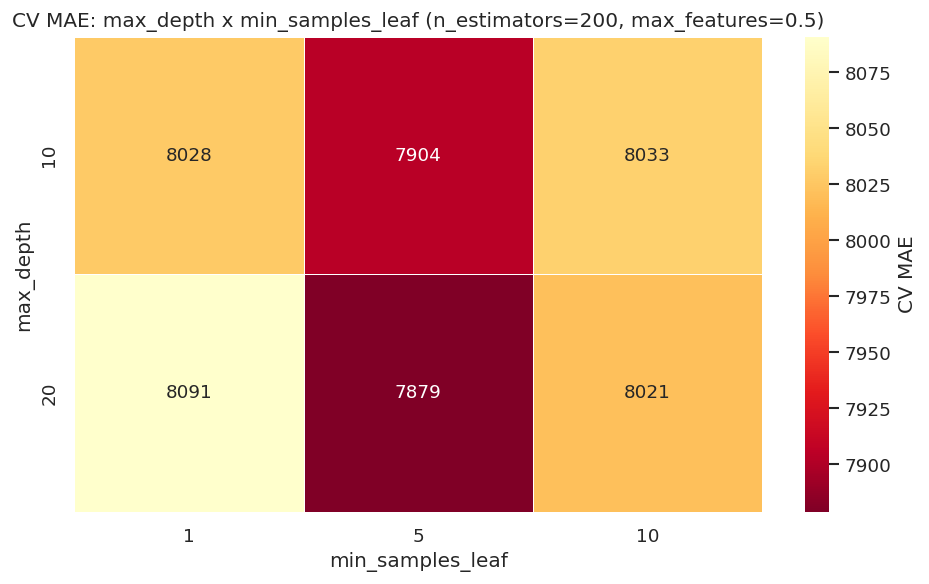

In [13]:
# Heatmapa: průměrné CV MAE pro kombinace max_depth × min_samples_leaf
best_n_est = grid_search.best_params_["n_estimators"]
best_mf    = grid_search.best_params_["max_features"]

pivot_data = (
    cv_results[
        (cv_results["param_n_estimators"] == best_n_est)
        & (cv_results["param_max_features"] == best_mf)
    ]
    .assign(mean_MAE=lambda d: (-d["mean_test_score"]).round(0))
    .pivot_table(
        index="param_max_depth",
        columns="param_min_samples_leaf",
        values="mean_MAE",
    )
)

fig, ax = plt.subplots(figsize=(8, 5))
sns.heatmap(
    pivot_data,
    ax=ax,
    annot=True,
    fmt=".0f",
    cmap="YlOrRd_r",
    cbar_kws={"label": "CV MAE"},
    linewidths=0.5,
)
ax.set_title(
    f"CV MAE: max_depth x min_samples_leaf "
    f"(n_estimators={best_n_est}, max_features={best_mf})"
)
ax.set_xlabel("min_samples_leaf")
ax.set_ylabel("max_depth")

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "step_05_gridsearch_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

### 8.5 Srovnání MAE: RF vs. Lineární regrese

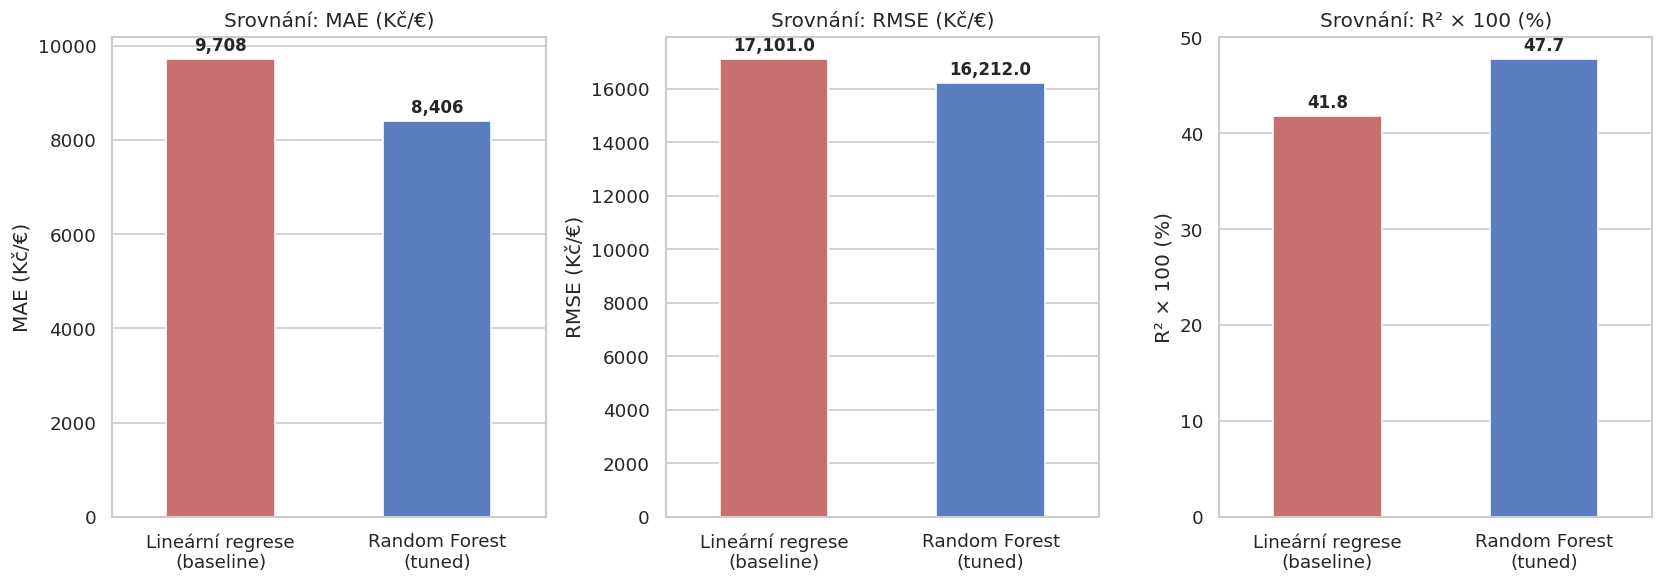

In [14]:
comp_plot = pd.DataFrame({
    "Model":  ["Lineární regrese\n(baseline)", "Random Forest\n(tuned)"],
    "MAE":    [int(metrics_lr.loc[0, "MAE"]), int(mae)],
    "RMSE":   [int(metrics_lr.loc[0, "RMSE"]), int(rmse)],
    "R²×100": [round(metrics_lr.loc[0, "R2"]*100, 1), round(r2*100, 1)],
})

fig, axes = plt.subplots(1, 3, figsize=(14, 5))
COLORS = [sns.color_palette("muted")[3], sns.color_palette("muted")[0]]

for ax, metric, ylabel in zip(
    axes,
    ["MAE", "RMSE", "R²×100"],
    ["MAE (Kč/€)", "RMSE (Kč/€)", "R² × 100 (%)"],
):
    bars = sns.barplot(
        data=comp_plot, x="Model", y=metric, ax=ax,
        palette=COLORS, width=0.5,
    )
    ax.set_title(f"Srovnání: {ylabel}")
    ax.set_xlabel("")
    ax.set_ylabel(ylabel)
    for bar, val in zip(ax.patches, comp_plot[metric]):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + comp_plot[metric].max() * 0.01,
            f"{val:,.1f}" if "R" in metric else f"{val:,.0f}",
            ha="center", va="bottom", fontsize=10, fontweight="bold",
        )

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "step_05_model_comparison.png", dpi=150, bbox_inches="tight")
plt.show()


## 9. Interpretace výsledků

**Random Forest překonal lineární regresi ve všech metrikách**, ale zlepšení je menší,  
než bychom u ensemble metody očekávali. MAE kleslo z 9 708 na 8 406 (−13,4 %),  
R² vzrostlo z 0.42 na 0.48. Klíčový problém zůstává stejný — třída nul (53 % zákazníků  
s CLV=0) výrazně "ředí" metriky: model predikuje relativně přesně pro neaktivní zákazníky,  
ale stále chybuje u vysokých CLV hodnot.

**Feature importance odhaluje překvapivý vzorec** oproti koeficientům lineárního modelu.  
Dominují `spend_trend_2y` a `app_usage_score` — Random Forest tak zachycuje nelineární  
interakci mezi trendem výdajů a digitálním engagementem, kterou lineární regrese přehlédla.  
`monetary_total`, které v korelační analýze (Krok 2) vedlo s r=0.62, se v RF umístilo až  
níže — pravděpodobně proto, že jeho informaci z velké části přenáší `spend_2024` a trendy.

**Residuální analýza** ukazuje zlepšení oproti LR: skewness residuí klesla, ale  
heteroskedasticita přetrvává — rozptyl chyb stále roste s výší predikce. Q-Q plot  
potvrzuje, že chvosty rozdělení jsou stále těžší než normální. RF tedy zvládl  
střed distribuce lépe, ale extrémní CLV hodnoty zůstávají problematické.

**GridSearch identifikoval optimální hloubku stromu = 20** — plné stromy (None)  
nepřinesly zlepšení a vedly k overfittingu, zatímco příliš mělké stromy (10)  
nestačily zachytit komplexitu dat. `min_samples_leaf=5` zabraňuje memorování  
šumu v listech, `max_features=0.5` zajišťuje dostatečnou diverzitu stromů.

**Závěr:** RF tvoří solidní střední úroveň výkonu. Očekáváme, že XGBoost  
(Krok 6) přinese další zlepšení díky boosting mechanismu, který cílí na  
zákazníky s největší chybou predikce a postupně ji snižuje.


## 10. Závěr & Přechod na Krok 6

In [15]:
# Uložení predikcí
predictions_df = pd.DataFrame({
    "account_external_id": df.loc[y_test.index, "account_external_id"].values,
    "clv_2025_actual":     y_test.values,
    "clv_2025_pred_rf":    y_pred,
})
try:
    predictions_df.to_csv(OUTPUT_DIR / "step_05_predictions.csv", index=False)
    print("✅ Predikce uloženy: step_05_predictions.csv")
except Exception as e:
    print(f"❌ Chyba: {e}")

# Uložení metrik pro srovnávací tabulku v Kroku 7
metrics_export = pd.DataFrame({
    "model":      ["RandomForest"],
    "MAE":        [round(mae, 0)],
    "RMSE":       [round(rmse, 0)],
    "R2":         [round(r2, 4)],
    "MAE_active": [round(mae_active, 0)],
    "R2_active":  [round(r2_active, 4)],
})
try:
    metrics_export.to_csv(OUTPUT_DIR / "step_05_metrics.csv", index=False)
    print("✅ Metriky uloženy: step_05_metrics.csv")
except Exception as e:
    print(f"❌ Chyba: {e}")

# Uložení feature importance pro SHAP srovnání v Kroku 6
fi_df.to_csv(OUTPUT_DIR / "step_05_feature_importance.csv", index=False)
print("✅ Feature importance uložena: step_05_feature_importance.csv")


✅ Predikce uloženy: step_05_predictions.csv
✅ Metriky uloženy: step_05_metrics.csv
✅ Feature importance uložena: step_05_feature_importance.csv


### Klíčová zjištění pro Krok 6 (XGBoost + SHAP)

1. **Vstupní soubor:** `outputs/step_02_features.csv` (stejný jako předchozí kroky)
2. **XGBoost** — gradient boosting na rozdíl od RF trénuje stromy sekvenčně;  
   každý strom opravuje chyby předchozího → lépe zvládá zákazníky s extrémním CLV
3. **Hyperparameter tuning:** `learning_rate`, `n_estimators`, `max_depth`,  
   `subsample`, `colsample_bytree`, `reg_alpha` (L1 regularizace)
4. **SHAP hodnoty** — na rozdíl od feature importance z RF jsou SHAP hodnoty  
   aditivní a konzistentní; ukáží nejen které features jsou důležité,  
   ale i v jakém směru a pro které zákazníky
5. **Metriky RF jako benchmark:** MAE={int(mae):,}, RMSE={int(rmse):,}, R²={round(r2,4)}
